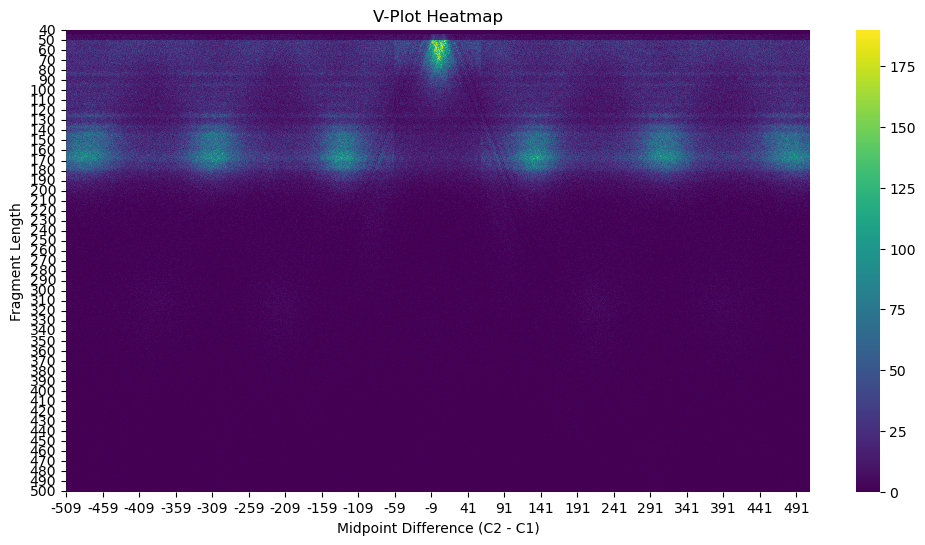

In [1]:
#v-plot
import gzip
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Parse data lines to extract X, Y, and count Z
from collections import defaultdict

# make_vplot(v_counter)
def parse_vplot(file_path):
    counter = defaultdict(lambda: defaultdict(int))
    with gzip.open(file_path, 'rt') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) >= 11:
                C1 = (int(parts[2]) + int(parts[3])) // 2
                C2 = (int(parts[8]) + int(parts[9])) // 2
                X = C2 - C1
                Y = int(parts[9]) - int(parts[8])
                counter[X][Y] += 1
    return counter

def create_vplot_heatmap(counter):
    data = []
    for x in counter:
        for y in counter[x]:
            data.append((x, y, counter[x][y]))
    
    df = pd.DataFrame(data, columns=['X', 'Y', 'Count'])
    pivot_table = df.pivot_table(index='Y', columns='X', values='Count', fill_value=0)

    plt.figure(figsize=(12, 6))
    sns.heatmap(pivot_table, cmap='viridis', xticklabels=50, yticklabels=10)
    plt.title("V-Plot Heatmap")
    plt.xlabel("Midpoint Difference (C2 - C1)")
    plt.ylabel("Fragment Length")
    plt.show()

# Usage:
counter = parse_vplot("mapped.bed.gz")
create_vplot_heatmap(counter)
